# PHI De-Identification Benchmark — all tools in one notebook

This notebook reproduces every column of our de-identification benchmark on the John Snow
Labs *Text2Story 2025* dataset (48 expert-annotated clinical documents, 1,479 PHI chunks):

| Tool | How it is run here | Needs |
|---|---|---|
| **John Snow Labs Healthcare NLP** | pretrained `clinical_deidentification_docwise_benchmark` pipeline | Healthcare NLP license |
| **GPT-5.5** | OpenAI Chat Completions, default settings, OpenAI prompt + system message | OpenAI API key |
| **Claude Opus 4.8** | Anthropic Messages, `max_tokens=8000`, Anthropic prompt | Anthropic API key |
| **Gemini 3.1 Pro (preview)** | Google GenAI, `temperature=0`, OpenAI prompt | Google API key |
| **GPT-5.6** | OpenAI Chat Completions, `reasoning_effort="high"`, OpenAI prompt + system message | OpenAI API key |
| **Claude Opus 5.5** | Anthropic Messages (streamed), adaptive thinking, `effort="high"`, Anthropic prompt | Anthropic API key |
| **Databricks `ai_mask`** | `ai_mask()` on a serverless SQL warehouse (or Databricks serverless compute) | Databricks workspace + token |


## 0. Setup

In [34]:
# Which tools to run. A tool set to False is taken from the published figures in section 12.
RUN = {
    "John Snow Labs":     False,
    "GPT-5.5":            False,
    "Claude Opus 4.8":    False,
    "Gemini 3.1 Pro":     False,
    "GPT-5.6":            False,
    "Claude Opus 5.5":    False,
    "Databricks ai_mask": False,
}

In [35]:
! pip install --upgrade -q openai anthropic google-genai databricks-sql-connector scikit-learn matplotlib openpyxl

In [36]:
# John Snow Labs: upload the license JSON (SECRET, JSL_VERSION, PUBLIC_VERSION, ...) and
# install Spark NLP for Healthcare. The Spark NLP Tokenizer is also used for token-level
# scoring, as in the original benchmark.
import json
import os

if RUN["John Snow Labs"]:
    if "spark_jsl.json" not in os.listdir():
        try:
            from google.colab import files
        except ImportError:
            raise RuntimeError(
                "John Snow Labs needs its license: put spark_jsl.json next to this notebook, "
                "or set RUN['John Snow Labs'] = False to use the published JSL figures.") from None
        license_keys = files.upload()
        os.rename(list(license_keys.keys())[0], "spark_jsl.json")

    with open("spark_jsl.json") as f:
        license_keys = json.load(f)

    # Defining license key-value pairs as local variables
    locals().update(license_keys)
    os.environ.update(license_keys)

    # pyspark 3.4.1 (the original pin) imports `typing.io`, which current Colab Python lacks.
    ! pip install --upgrade -q pyspark==3.5.5 spark-nlp==$PUBLIC_VERSION
    ! pip install --upgrade -q spark-nlp-jsl==$JSL_VERSION --extra-index-url https://pypi.johnsnowlabs.com/$SECRET
else:
    print("John Snow Labs skipped — no license needed")

John Snow Labs skipped — no license needed


If Colab asks to **restart the session** after the install, restart, run the cells above once
more (the license is re-read from `spark_jsl.json`), then continue.

In [37]:
# Optional: keep the cache on Google Drive so it survives a runtime reset, then set
# CACHE_DIR below to e.g. "/content/drive/MyDrive/deid_benchmark".
# from google.colab import drive
# drive.mount("/content/drive")

## 1. Configuration and credentials

In [38]:
import os, re, ast, json, time, threading, difflib
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd

pd.set_option("display.max_colwidth", 200)

GROUND_TRUTH_URL = (
    "https://raw.githubusercontent.com/JohnSnowLabs/spark-nlp-workshop/master/"
    "tutorials/academic/DeIdentification_Benchmarks_Text2Story2025/"
    "deidentification_benchmark_ground_truth_48_doc.csv"
)

# Raw model outputs are cached here, per tool and per document.
CACHE_DIR = "benchmark_outputs"
os.makedirs(CACHE_DIR, exist_ok=True)

GT_LABELS = ["NAME", "DATE", "AGE", "LOCATION", "IDNUM", "CONTACT"]

# LLM settings — each entry reproduces how that model was run for the published figures.
MODELS = {
    "GPT-5.5": {
        "provider": "openai", "model_id": "gpt-5.5", "prompt": "openai",
        "reasoning_effort": None,          # API default, as in the original run
        "max_output_tokens": None,         # API default
    },
    "Claude Opus 4.8": {
        "provider": "anthropic", "model_id": "claude-opus-4-8", "prompt": "anthropic",
        "thinking": False, "effort": None,
        "max_output_tokens": 8_000,
    },
    "Gemini 3.1 Pro": {
        "provider": "google", "model_id": "gemini-3.1-pro-preview", "prompt": "openai",
        "temperature": 0,
    },
    "GPT-5.6": {
        "provider": "openai", "model_id": "gpt-5.6", "prompt": "openai",
        "reasoning_effort": "high",
        "max_output_tokens": 64_000,
    },
    "Claude Opus 5.5": {
        "provider": "anthropic", "model_id": "claude-opus-5-5", "prompt": "anthropic",
        "thinking": True, "effort": "high",
        "max_output_tokens": 64_000,
    },
}

MAX_WORKERS = 6          # concurrent requests per model; lower it if you hit rate limits
MAX_ATTEMPTS = 3         # attempts per document per run of a model cell
RETRY_WAIT_S = 30        # pause between retry rounds
REQUEST_TIMEOUT_S = 900  # give up on a single request after 15 minutes
SDK_RETRIES = 2          # the SDKs' own quick retries for 429 / 5xx / connection errors

# Databricks ai_mask
#   "sql_warehouse"  -> from Colab, through a serverless SQL warehouse
#   "spark"          -> when this notebook itself runs on Databricks serverless compute
AI_MASK_BACKEND = "sql_warehouse"
AI_MASK_WORKERS = 4      # concurrent documents sent to the warehouse
AI_MASK_SMOKE_TIMEOUT_S = 300   # the smoke test gives up after this (a stopped warehouse needs time to start)

In [39]:
# Credentials. Leave a value empty to read it from Colab secrets or the environment instead.
OPENAI_API_KEY = ""
ANTHROPIC_API_KEY = ""
GOOGLE_API_KEY = ""
DATABRICKS_SERVER_HOSTNAME = ""   # e.g. "adb-1234567890123456.7.azuredatabricks.net"
DATABRICKS_HTTP_PATH = ""         # SQL warehouse -> Connection details -> HTTP path
DATABRICKS_TOKEN = ""             # personal access token


def secret(name, value):
    if value:
        return value
    try:
        from google.colab import userdata
        return userdata.get(name)
    except Exception:
        return os.environ.get(name, "")


OPENAI_API_KEY = secret("OPENAI_API_KEY", OPENAI_API_KEY)
ANTHROPIC_API_KEY = secret("ANTHROPIC_API_KEY", ANTHROPIC_API_KEY)
GOOGLE_API_KEY = secret("GOOGLE_API_KEY", GOOGLE_API_KEY)
DATABRICKS_SERVER_HOSTNAME = secret("DATABRICKS_SERVER_HOSTNAME", DATABRICKS_SERVER_HOSTNAME)
DATABRICKS_HTTP_PATH = secret("DATABRICKS_HTTP_PATH", DATABRICKS_HTTP_PATH)
DATABRICKS_TOKEN = secret("DATABRICKS_TOKEN", DATABRICKS_TOKEN)

N_DOCS = 48


def fully_cached(name):
    '''True when every document already has an `ok` answer in CACHE_DIR — no API call needed.'''
    p = os.path.join(CACHE_DIR, re.sub(r"[^\w.-]+", "_", name) + ".json")
    if not os.path.exists(p):
        return False
    recs = json.load(open(p)).values()
    return len(recs) >= N_DOCS and all(r.get("status") == "ok" for r in recs)


needed = {"openai": OPENAI_API_KEY, "anthropic": ANTHROPIC_API_KEY, "google": GOOGLE_API_KEY}
for name, cfg in MODELS.items():
    if RUN[name] and not fully_cached(name) and not needed[cfg["provider"]]:
        raise ValueError(f"{name} is enabled but no {cfg['provider']} API key is set")
if RUN["Databricks ai_mask"] and AI_MASK_BACKEND == "sql_warehouse" and not all(
        [DATABRICKS_SERVER_HOSTNAME, DATABRICKS_HTTP_PATH, DATABRICKS_TOKEN]):
    raise ValueError("Databricks ai_mask is enabled but the SQL warehouse credentials are missing")
print("credentials OK for:", [t for t, on in RUN.items() if on])

credentials OK for: []


## 2. Ground truth (48 documents, 1,479 annotated chunks)

In [40]:
ground_truth_df = pd.read_csv(GROUND_TRUTH_URL)
docs_df = ground_truth_df[["doc_id", "text"]].drop_duplicates().reset_index(drop=True)

print(ground_truth_df.shape, "|", len(docs_df), "documents")
print(ground_truth_df.chunk_label.value_counts())

(1479, 6) | 48 documents
chunk_label
DATE        582
NAME        380
LOCATION    236
IDNUM       185
CONTACT      49
AGE          47
Name: count, dtype: int64


## 3. John Snow Labs Healthcare NLP

Same pretrained pipeline and the same `ner_chunk` → span extraction as the original benchmark,
including `end + 1` (Spark NLP ends are inclusive, the ground truth's are exclusive). The
predictions are cached; the Spark session is still started because section 10 uses the Spark
NLP `Tokenizer`.

In [41]:
# `spark` is only (re)bound when JSL runs, so on Databricks the workspace's own session stays
# available for ai_mask; the Spark NLP Tokenizer in section 10 uses `jsl_spark`.
jsl_spark = None
jsl_df, jsl_elapsed = None, None

if RUN["John Snow Labs"]:
    import sparknlp
    import sparknlp_jsl
    from pyspark.sql import functions as F

    params = {"spark.driver.memory": "16G",
              "spark.kryoserializer.buffer.max": "2000M",
              "spark.driver.maxResultSize": "2000M"}
    spark = jsl_spark = sparknlp_jsl.start(license_keys["SECRET"], params=params)
    print("Spark NLP:", sparknlp.version(), "| Spark NLP for Healthcare:", sparknlp_jsl.version())

In [42]:
def run_jsl():
    cache = os.path.join(CACHE_DIR, "john_snow_labs_predictions.csv")
    if os.path.exists(cache):
        df = pd.read_csv(cache, keep_default_na=False)
        print(f"loaded {len(df)} cached JSL spans from {cache}")
        return df, None

    from sparknlp.pretrained import PretrainedPipeline
    deid_pipeline = PretrainedPipeline("clinical_deidentification_docwise_benchmark", "en", "clinical/models")
    spark_df = spark.createDataFrame(docs_df).repartition(32)

    t0 = time.time()
    result = deid_pipeline.model.transform(spark_df)
    res_df = result.select("doc_id", "text", F.explode(F.arrays_zip(result.ner_chunk.begin,
                                                                    result.ner_chunk.end,
                                                                    result.ner_chunk.result,
                                                                    result.ner_chunk.metadata)).alias("cols")) \
                   .select("doc_id", "text", F.expr("cols['0']").alias("begin"),
                                             F.expr("cols['1']").alias("end"),
                                             F.expr("cols['2']").alias("chunk"),
                                             F.expr("cols['3']['entity']").alias("chunk_label")
                          ).toPandas()
    elapsed = time.time() - t0

    res_df = res_df.sort_values(["doc_id", "begin"]).reset_index(drop=True)
    res_df.end = res_df.end + 1
    res_df = res_df.drop(columns=["text"])
    res_df.to_csv(cache, index=False)
    print(f"JSL pipeline: {len(docs_df)} documents in {elapsed:.1f}s")
    return res_df, elapsed


if RUN["John Snow Labs"]:
    res_df, jsl_elapsed = run_jsl()
    jsl_df = res_df[res_df.chunk_label.isin(GT_LABELS)].reset_index(drop=True)
    print(jsl_df.chunk_label.value_counts())
else:
    print("John Snow Labs skipped")

John Snow Labs skipped


## 4. LLM prompts — verbatim from the original benchmark

The original benchmark used one prompt for OpenAI models and a slightly stricter one for
Claude. Each vendor keeps its own prompt, unchanged; Gemini was run with the OpenAI prompt.

In [43]:
def create_prompt(text):
    """OpenAI prompt, verbatim from the original notebook (used with GPT-4o / GPT-4.5)."""
    return f"""You are an expert medical annotator with extensive experience in labeling medical entities within clinical texts. Your role is to accurately identify and annotate Protected Health Information (PHI) entities in the provided text, following the specified entity types.

    ### Instructions:
    1. **Review the Text**: Carefully read the text to understand its medical context.
    2. **Identify PHI Entities**: Locate any terms or phrases that represent PHI, based on the following entity types:
    - IDNUM, LOCATION, DATE, AGE, NAME, CONTACT
    3. **Annotate Entities**: For each identified PHI, provide the start and end character indices, the entity type, and the exact text (chunk) of the entity.
    4. **Response Format**: Return the annotations in a structured JSON format, as demonstrated in the examples below.

    ### Example:

    **Input Sentence:**
    "MD Connect Call 11:59pm 2/16/69 from Dr. Hale at Senior Care Clinic Queen Creek, SD regarding Terri Bird."

    **Annotated Entities:**
    [
        {{'begin': 24, 'end': 30, 'entity_type': 'DATE', 'chunk': '2/16/69'}},
        {{'begin': 42, 'end': 45, 'entity_type': 'NAME', 'chunk': 'Hale'}},
        {{'begin': 50, 'end': 67, 'entity_type': 'LOCATION', 'chunk': 'Senior Care Clinic'}},
        {{'begin': 69, 'end': 79, 'entity_type': 'LOCATION', 'chunk': 'Queen Creek'}},
        {{'begin': 83, 'end': 84, 'entity_type': 'LOCATION', 'chunk': 'SD'}},
        {{'begin': 96, 'end': 105, 'entity_type': 'NAME', 'chunk': 'Terri Bird'}}
    ]

    ---

    ### Task:

    Extract all PHI entities from the text below. The entity types to identify are: **IDNUM, LOCATION, DATE, AGE, NAME, CONTACT**.

    **Expected Output Format:**
    {{
        entities:[
            {{'begin': <start_index>, 'end': <end_index>, 'entity_type': '<entity_type>', 'chunk': '<extracted_text>'}}
        ]
    }}

    ---

    ### Text to Annotate:

    {text}

    ---

    ### Your Response:
    """

OPENAI_SYSTEM = ("You are an expert medical annotator with extensive experience in labeling "
                 "PHI entities within clinical texts.")


def get_prompt(text):
    """Anthropic prompt, verbatim from the original notebook (used with Claude 3.7 Sonnet)."""
    prompt = f"""
    You are an expert medical annotator with extensive experience in labeling medical entities within clinical texts. Your role is to accurately identify and annotate Protected Health Information (PHI) entities in the provided text, following the specified entity types.

    ### Instructions:
    1. **Review the Text**: Carefully read the text to understand its medical context.
    2. **Identify PHI Entities**: Locate any terms or phrases that represent PHI, based on the following entity types:
    - IDNUM, LOCATION, DATE, AGE, NAME, CONTACT
    3. **Annotate Entities**: For each identified PHI, provide the start and end character indices, the entity type, and the exact text (chunk) of the entity.
    4. **Response Format**: Return the annotations in a structured JSON format, as demonstrated in the examples below.
    5. DO NOT return any other text or explanation like 'Here is the entities..' or 'JSON:...'.

    ### Example:

    **Input Sentence:**
    "MD Connect Call 11:59pm 2/16/69 from Dr. Hale at Senior Care Clinic Queen Creek, SD regarding Terri Bird."

    **Annotated Entities:**
    [
        {{'begin': 24, 'end': 30, 'entity_type': 'DATE', 'chunk': '2/16/69'}},
        {{'begin': 42, 'end': 45, 'entity_type': 'NAME', 'chunk': 'Hale'}},
        {{'begin': 50, 'end': 67, 'entity_type': 'LOCATION', 'chunk': 'Senior Care Clinic'}},
        {{'begin': 69, 'end': 79, 'entity_type': 'LOCATION', 'chunk': 'Queen Creek'}},
        {{'begin': 83, 'end': 84, 'entity_type': 'LOCATION', 'chunk': 'SD'}},
        {{'begin': 96, 'end': 105, 'entity_type': 'NAME', 'chunk': 'Terri Bird'}}
    ]

    ---

    ### Task:

    Extract all PHI entities from the text below. DO NOT return any other text or explanation like 'Here is the entities..'. The ONLY PHI entity types to identify are: **IDNUM, LOCATION, DATE, AGE, NAME, CONTACT**.

    Expected Output Format:
    {{
        entities:[
            {{'begin': <start_index>, 'end': <end_index>, 'entity_type': '<entity_type>', 'chunk': '<extracted_text>'}}
        ]
    }}

    ---

    ### Text to Annotate:

    {text}

    ---

    ### Your Response:
    """

    return prompt

PROMPTS = {"openai": create_prompt, "anthropic": get_prompt}

## 5. LLM runner

One request per document per model. Every answer is checked before it counts as a success: a
document **fails an attempt** when the API call raises, the model refuses, the answer is cut off
at the output-token limit, is empty, or cannot be parsed into an entity list. Failed documents
are retried automatically in rounds (`MAX_ATTEMPTS`); errors a retry cannot fix (bad key,
unknown model ID) stop immediately.

`CACHE_DIR/<model>.json` keeps the latest answer per document, so re-running a model cell only
sends the documents that are not `ok` yet. `CACHE_DIR/run_log.csv` gets one line per attempt.

In [44]:
def parse_entities(raw):
    '''Model text -> list of entity dicts, or None if unreadable.

    The prompt's example uses single-quoted, Python-style dicts and an unquoted `entities`
    key, so a strict json.loads fails on some perfectly readable answers. Try JSON, then
    ast.literal_eval, each with the bare key quoted too.
    '''
    if not raw:
        return None
    s = re.sub(r"^\s*```(?:json|python)?\s*|\s*```\s*$", "", raw.strip())
    candidates = []
    if "{" in s:
        candidates.append(s[s.find("{"): s.rfind("}") + 1])
    if "[" in s:
        candidates.append(s[s.find("["): s.rfind("]") + 1])

    for c in candidates:
        for variant in (c, re.sub(r"(?<=[{,\s])entities\s*:", '"entities":', c)):
            for loader in (json.loads, ast.literal_eval):
                try:
                    obj = loader(variant)
                except Exception:
                    continue
                if isinstance(obj, dict) and isinstance(obj.get("entities"), list):
                    return obj["entities"]
                if isinstance(obj, list):
                    return obj
    return None


# Exceptions a retry cannot fix (same class names in the openai and anthropic SDKs; google-genai
# raises ClientError with an HTTP `code`, where 429 stays retryable).
FATAL_ERRORS = {"AuthenticationError", "PermissionDeniedError", "NotFoundError",
                "BadRequestError", "UnprocessableEntityError"}
CALLERS = {}   # provider -> function(cfg, text) -> dict; filled in section 6


def call_model(name, text):
    '''One attempt: call the model, then decide whether the answer is usable.'''
    cfg = MODELS[name]
    t0 = time.time()
    try:
        out = CALLERS[cfg["provider"]](cfg, text)
    except Exception as e:
        out = {"raw": None, "stop_reason": None, "input_tokens": 0, "output_tokens": 0,
               "error": f"{type(e).__name__}: {e}"[:300],
               "fatal": type(e).__name__ in FATAL_ERRORS
                        or getattr(e, "code", None) in (400, 401, 403, 404)}
    out["latency_s"] = round(time.time() - t0, 1)

    if not out.get("error"):
        if out["stop_reason"] in ("length", "max_tokens", "MAX_TOKENS"):
            out["error"] = f"truncated at the output-token limit ({out['stop_reason']})"
        elif not (out["raw"] or "").strip():
            out["error"] = f"empty response (stop_reason={out['stop_reason']})"
        elif parse_entities(out["raw"]) is None:
            out["error"] = "response could not be parsed as an entity list"
    out.setdefault("error", None)
    out.setdefault("fatal", False)
    return out


RUN_LOG = os.path.join(CACHE_DIR, "run_log.csv")
_lock = threading.Lock()


def _cache_path(name):
    return os.path.join(CACHE_DIR, re.sub(r"[^\w.-]+", "_", name) + ".json")


def load_cache(name):
    p = _cache_path(name)
    if not os.path.exists(p):
        return {}
    with open(p) as f:
        return {int(k): v for k, v in json.load(f).items()}


def _save(name, cache, log_row):
    '''Persist after every attempt, so a disconnect loses at most the in-flight calls.'''
    with _lock:
        with open(_cache_path(name), "w") as f:
            json.dump({str(k): v for k, v in cache.items()}, f)
        new_file = not os.path.exists(RUN_LOG)
        pd.DataFrame([log_row]).to_csv(RUN_LOG, mode="a", header=new_file, index=False)


def _attempt(name, doc_id, text, cache):
    out = call_model(name, text)
    prev = cache.get(doc_id, {})
    attempts = prev.get("attempts", 0) + 1
    history = prev.get("errors", []) + ([out["error"]] if out["error"] else [])
    rec = {**out, "status": "ok" if not out["error"] else "failed",
           "attempts": attempts, "errors": history}
    cache[doc_id] = rec
    _save(name, cache, {
        "time": time.strftime("%Y-%m-%d %H:%M:%S"), "model": name, "doc_id": doc_id,
        "attempt": attempts, "outcome": rec["status"], "error": out["error"],
        "stop_reason": out["stop_reason"], "latency_s": out["latency_s"],
        "input_tokens": out["input_tokens"], "output_tokens": out["output_tokens"],
    })
    return rec


def run_model(name):
    '''Call every document that is not `ok` yet; retry failures in rounds.'''
    cache = load_cache(name)
    texts = dict(zip(docs_df.doc_id, docs_df.text))
    pending = [d for d in texts if cache.get(d, {}).get("status") != "ok"]
    if not pending:
        print(f"{name}: all {len(texts)} documents already ok (cached)")
        return cache

    t0 = time.time()
    for round_no in range(1, MAX_ATTEMPTS + 1):
        if round_no > 1:
            print(f"  waiting {RETRY_WAIT_S}s before retrying {len(pending)} document(s)")
            time.sleep(RETRY_WAIT_S)
        print(f"{name} · round {round_no}: sending {len(pending)} document(s)")
        recs = {}
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
            futures = {pool.submit(_attempt, name, d, texts[d], cache): d for d in pending}
            for fut in as_completed(futures):
                d, r = futures[fut], fut.result()
                recs[d] = r
                result = "ok" if r["status"] == "ok" else f"FAILED — {r['error']}"
                print(f"  [{len(recs):>2}/{len(pending)}] doc {d:>3}  {r['latency_s']:>6.1f}s  "
                      f"{r['output_tokens']:>6,} out tok  {result}", flush=True)
        failed = [d for d, r in recs.items() if r["status"] != "ok"]
        print(f"{name} · round {round_no}: {len(pending) - len(failed)} ok, {len(failed)} failed")
        pending = [d for d in failed if not recs[d]["fatal"]]
        if len(pending) < len(failed):
            print(f"  {len(failed) - len(pending)} fatal error(s) — not retrying; fix the config and re-run")
        if not pending:
            break
    print(f"{name}: finished in {time.time() - t0:.0f}s\n")
    return cache


def smoke_test(name):
    '''One call on the shortest document before spending on all 48.'''
    shortest = docs_df.loc[docs_df.text.str.len().idxmin()]
    r = call_model(name, shortest.text)
    print(f"{name}  doc {shortest.doc_id}  stop={r['stop_reason']}  "
          f"in={r['input_tokens']} out={r['output_tokens']}  {r['latency_s']}s  ->",
          "OK" if not r["error"] else f"FAILED — {r['error']}")
    if r["fatal"]:
        raise RuntimeError(f"{name}: {r['error']}")


raw_outputs = {}

## 6. Model calls — one section per model

Each caller reproduces the request of the original run. The model-specific settings live in
`MODELS` (section 1).

In [45]:
# Clients only for providers that still have documents to send (a fully cached model
# needs neither its SDK nor its key).
live = {MODELS[n]["provider"] for n in MODELS if RUN[n] and not fully_cached(n)}
openai_client = anthropic_client = gemini_client = genai_types = None
if "openai" in live:
    from openai import OpenAI
    openai_client = OpenAI(api_key=OPENAI_API_KEY, timeout=REQUEST_TIMEOUT_S, max_retries=SDK_RETRIES)
if "anthropic" in live:
    import anthropic
    anthropic_client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY,
                                           timeout=REQUEST_TIMEOUT_S, max_retries=SDK_RETRIES)
if "google" in live:
    from google import genai
    from google.genai import types as genai_types
    gemini_client = genai.Client(api_key=GOOGLE_API_KEY)
print("API clients:", sorted(live) or "none — every enabled model is served from the cache")

def call_openai(cfg, text):
    '''Chat Completions with the OpenAI prompt + system message (original notebook).'''
    kwargs = dict(
        model=cfg["model_id"],
        messages=[{"role": "system", "content": OPENAI_SYSTEM},
                  {"role": "user", "content": PROMPTS[cfg["prompt"]](text)}],
    )
    if cfg.get("max_output_tokens"):
        kwargs["max_completion_tokens"] = cfg["max_output_tokens"]
    if cfg.get("reasoning_effort"):
        kwargs["reasoning_effort"] = cfg["reasoning_effort"]
    resp = openai_client.chat.completions.create(**kwargs)
    choice = resp.choices[0]
    return {"raw": choice.message.content, "stop_reason": choice.finish_reason,
            "input_tokens": resp.usage.prompt_tokens,
            "output_tokens": resp.usage.completion_tokens}   # includes reasoning tokens


def call_anthropic(cfg, text):
    '''Messages API with the Anthropic prompt. Streamed, so 64k-token answers stay under the
    SDK's HTTP timeout. Thinking/effort only for models run that way (Opus 5.5).'''
    kwargs = dict(model=cfg["model_id"], max_tokens=cfg["max_output_tokens"],
                  messages=[{"role": "user", "content": PROMPTS[cfg["prompt"]](text)}])
    if cfg.get("thinking"):
        kwargs["thinking"] = {"type": "adaptive"}
    if cfg.get("effort"):
        kwargs["output_config"] = {"effort": cfg["effort"]}
    with anthropic_client.messages.stream(**kwargs) as stream:
        msg = stream.get_final_message()

    out = {"raw": "".join(b.text for b in msg.content if b.type == "text"),
           "stop_reason": msg.stop_reason,
           "input_tokens": msg.usage.input_tokens,
           "output_tokens": msg.usage.output_tokens}   # includes thinking tokens
    if msg.stop_reason == "refusal":
        out["error"] = "refusal"
    return out


def call_google(cfg, text):
    '''Google GenAI with the OpenAI prompt and temperature=0 (original notebook).'''
    resp = gemini_client.models.generate_content(
        model=cfg["model_id"],
        contents=PROMPTS[cfg["prompt"]](text),
        config=genai_types.GenerateContentConfig(temperature=cfg["temperature"]),
    )
    usage = resp.usage_metadata
    finish = resp.candidates[0].finish_reason if resp.candidates else None
    return {"raw": resp.text, "stop_reason": getattr(finish, "name", finish),
            "input_tokens": getattr(usage, "prompt_token_count", 0) or 0,
            "output_tokens": (getattr(usage, "candidates_token_count", 0) or 0)
                             + (getattr(usage, "thoughts_token_count", 0) or 0)}


CALLERS.update({"openai": call_openai, "anthropic": call_anthropic, "google": call_google})

API clients: none — every enabled model is served from the cache


### 6.1 GPT-5.5

OpenAI prompt + system message, API defaults (no `reasoning_effort`, no token cap).

In [46]:
NAME = "GPT-5.5"
if RUN[NAME]:
    if not fully_cached(NAME):
        smoke_test(NAME)
    raw_outputs[NAME] = run_model(NAME)
else:
    print(NAME, "skipped")

GPT-5.5 skipped


### 6.2 Claude Opus 4.8

Anthropic prompt, `max_tokens=8000`, no extended thinking.

In [47]:
NAME = "Claude Opus 4.8"
if RUN[NAME]:
    if not fully_cached(NAME):
        smoke_test(NAME)
    raw_outputs[NAME] = run_model(NAME)
else:
    print(NAME, "skipped")

Claude Opus 4.8 skipped


### 6.3 Gemini 3.1 Pro

OpenAI prompt, `temperature=0`, model `gemini-3.1-pro-preview`.

In [48]:
NAME = "Gemini 3.1 Pro"
if RUN[NAME]:
    if not fully_cached(NAME):
        smoke_test(NAME)
    raw_outputs[NAME] = run_model(NAME)
else:
    print(NAME, "skipped")

Gemini 3.1 Pro skipped


### 6.4 GPT-5.6

OpenAI prompt + system message, `reasoning_effort="high"`, `max_completion_tokens=64000`. GPT-5.x reasoning models accept only the default temperature.

In [49]:
NAME = "GPT-5.6"
if RUN[NAME]:
    if not fully_cached(NAME):
        smoke_test(NAME)
    raw_outputs[NAME] = run_model(NAME)
else:
    print(NAME, "skipped")

GPT-5.6 skipped


### 6.5 Claude Opus 5.5

Anthropic prompt, adaptive thinking, `effort="high"`, `max_tokens=64000`. Opus 5.5 rejects sampling parameters, so there is no `temperature=0`.

In [50]:
NAME = "Claude Opus 5.5"
if RUN[NAME]:
    if not fully_cached(NAME):
        smoke_test(NAME)
    raw_outputs[NAME] = run_model(NAME)
else:
    print(NAME, "skipped")

Claude Opus 5.5 skipped


### 6.6 Run status

In [51]:
# Anything under "failed" is scored as zero predictions for that document — re-run that
# model's cell to retry exactly those documents.
status_rows, failed_rows = [], []
for name, outputs in raw_outputs.items():
    recs = [outputs.get(d, {}) for d in docs_df.doc_id]
    ok = [r for r in recs if r.get("status") == "ok"]
    status_rows.append({"model": name,
                        "ok on 1st attempt": sum(r["attempts"] == 1 for r in ok),
                        "ok after retry": sum(r["attempts"] > 1 for r in ok),
                        "failed": len(recs) - len(ok)})
    failed_rows += [{"model": name, "doc_id": d, "last error": r.get("error")}
                    for d, r in sorted(outputs.items()) if r.get("status") != "ok"]
if status_rows:
    display(pd.DataFrame(status_rows).set_index("model"))
if failed_rows:
    display(pd.DataFrame(failed_rows))

## 7. Databricks `ai_mask`

`ai_mask(content, labels)` returns rewritten text with entities replaced by `[MASKED]` — no
spans, no labels. Eight masked columns are produced per document:

| Column | Call | Used for |
|---|---|---|
| `masked_<LABEL>` × 6 | one call per ground-truth label | per-entity precision / recall / F1, chunk level |
| `masked_ALL` | one call, full 18-label list | PHI / non-PHI (diagnostic) |
| `masked_ALL6` | one call, six broad labels | PHI / non-PHI — the published `ai_mask` PHI row |

The label lists are the ones used for the published run. Spans are recovered afterwards by
diffing the masked text against the original (section 7.1).

Backend: from Colab, each document is sent to a **serverless SQL warehouse** through
`databricks-sql-connector`; when this notebook itself runs on Databricks serverless compute,
set `AI_MASK_BACKEND = "spark"` and all documents go through one Spark job, as in the
published run.

In [52]:
# Ground-truth label -> the natural-language labels handed to ai_mask.
LABEL_MAP = {
    "NAME":     ["person name", "patient name", "doctor name"],
    "DATE":     ["date"],
    "AGE":      ["age"],
    "LOCATION": ["street address", "city", "state", "zip code", "hospital name", "location"],
    "IDNUM":    ["identification number", "medical record number", "social security number",
                 "account number"],
    "CONTACT":  ["phone number", "fax number", "email address"],
}
ALL_LABELS = sorted({l for labels in LABEL_MAP.values() for l in labels})
ALL_LABELS_BROAD = ["person name", "date", "age", "location", "identification number",
                    "contact information"]
MAX_SPAN_CHARS = 120     # a recovered span longer than this is a diff artifact

AI_MASK_COLS = {f"masked_{gt}": labels for gt, labels in LABEL_MAP.items()}
AI_MASK_COLS["masked_ALL"] = ALL_LABELS
AI_MASK_COLS["masked_ALL6"] = ALL_LABELS_BROAD
AI_MASK_CACHE = os.path.join(CACHE_DIR, "ai_mask_outputs.json")


def _sql_array(labels):
    inner = ", ".join("'" + l.replace("'", "''") + "'" for l in labels)
    return f"array({inner})"


def ai_mask_one_doc_sql(text, columns):
    '''All requested masked columns for one document, in one warehouse query.'''
    from databricks import sql as dbsql
    select = ", ".join(f"ai_mask(t, {_sql_array(labels)}) AS {col}" for col, labels in columns.items())
    with dbsql.connect(server_hostname=DATABRICKS_SERVER_HOSTNAME, http_path=DATABRICKS_HTTP_PATH,
                       access_token=DATABRICKS_TOKEN) as conn, conn.cursor() as cur:
        cur.execute(f"WITH d AS (SELECT :t AS t) SELECT {select} FROM d", {"t": text})
        row = cur.fetchone()
        return {col: row[i] for i, col in enumerate(columns)}


def run_ai_mask():
    cache = {}
    if os.path.exists(AI_MASK_CACHE):
        cache = {int(k): v for k, v in json.load(open(AI_MASK_CACHE)).items()}
    todo = {d: {c: l for c, l in AI_MASK_COLS.items() if c not in cache.get(d, {})}
            for d in docs_df.doc_id}
    todo = {d: cols for d, cols in todo.items() if cols}
    if not todo:
        print(f"all {len(AI_MASK_COLS)} masked columns cached for {len(docs_df)} documents")
        return cache, None

    texts = dict(zip(docs_df.doc_id, docs_df.text))
    t0 = time.time()
    if AI_MASK_BACKEND == "spark":
        # One Spark job, as in the published run (Databricks serverless compute only).
        from pyspark.sql import functions as F
        needed = sorted({c for cols in todo.values() for c in cols})
        sdf = spark.createDataFrame(docs_df[docs_df.doc_id.isin(list(todo))]).repartition(16)
        exprs = [F.col("doc_id")] + [F.expr(f"ai_mask(text, {_sql_array(AI_MASK_COLS[c])})").alias(c)
                                     for c in needed]
        out = sdf.select(*exprs).toPandas()
        for r in out.to_dict("records"):
            cache.setdefault(int(r.pop("doc_id")), {}).update(r)
        json.dump({str(k): v for k, v in cache.items()}, open(AI_MASK_CACHE, "w"))
        print(f"{len(out)} documents x {len(needed)} columns via Spark")
    else:
        done = 0
        with ThreadPoolExecutor(max_workers=AI_MASK_WORKERS) as pool:
            futures = {pool.submit(ai_mask_one_doc_sql, texts[d], cols): d for d, cols in todo.items()}
            for fut in as_completed(futures):
                d = futures[fut]
                done += 1
                try:
                    cache.setdefault(d, {}).update(fut.result())
                    with _lock:
                        json.dump({str(k): v for k, v in cache.items()}, open(AI_MASK_CACHE, "w"))
                    print(f"  [{done:>2}/{len(todo)}] doc {d:>3}  {len(todo[d])} column(s)  ok", flush=True)
                except Exception as e:
                    print(f"  [{done:>2}/{len(todo)}] doc {d:>3}  FAILED — {type(e).__name__}: {e}"[:300],
                          flush=True)
    elapsed = time.time() - t0
    print(f"ai_mask: finished in {elapsed:.0f}s — re-run this cell to retry any failed document")
    return cache, elapsed


if RUN["Databricks ai_mask"] and AI_MASK_BACKEND == "sql_warehouse":
    # Smoke test before sending all 48 documents: a wrong host / token / warehouse type
    # (ai_mask is not available on Classic warehouses) or region fails here. The connector
    # keeps retrying an unreachable host for many minutes, so the probe has its own time limit.
    from concurrent.futures import TimeoutError as FutureTimeout
    probe_pool = ThreadPoolExecutor(max_workers=1)
    probe = probe_pool.submit(ai_mask_one_doc_sql, "Patient John Smith was seen on 02/03/2024 in Boston.",
                              {"probe": ["person name", "date", "city"]})
    probe_pool.shutdown(wait=False)
    try:
        print("ai_mask smoke test:", probe.result(timeout=AI_MASK_SMOKE_TIMEOUT_S)["probe"])
    except FutureTimeout:
        raise TimeoutError(
            f"No answer from the SQL warehouse in {AI_MASK_SMOKE_TIMEOUT_S}s. Check DATABRICKS_SERVER_HOSTNAME, "
            "DATABRICKS_HTTP_PATH and DATABRICKS_TOKEN; a stopped warehouse may need a few minutes to start.") from None

ai_mask_raw, ai_mask_elapsed = (run_ai_mask() if RUN["Databricks ai_mask"] else ({}, None))
if not RUN["Databricks ai_mask"]:
    print("Databricks ai_mask skipped")

Databricks ai_mask skipped


### 7.1 Span recovery

Each `[MASKED]` placeholder is replaced by a sentinel character, both texts are tokenized, and
`difflib.SequenceMatcher` runs over the token sequences. Every non-`equal` opcode that consumes
original tokens is a detected span. Code as in the published `ai_mask` run.

In [53]:
SENTINEL = "￿"
# Exactly the placeholder ai_mask documents, nothing looser. A permissive bracket pattern
# (`\[[A-Za-z0-9 _-]{2,40}\]`) also swallows bracketed text that is in the *source*
# documents — 34 of these 48 end with "[ report_end ]", and there are "[Penicillins]",
# "[hives]", "[U99996]" too — turning each one into a phantom detected span in every pass.
PLACEHOLDER_RE = re.compile(r"\[MASKED\]")
PUNCT_ONLY_RE = re.compile(r"^[^\w]+$")
# Stand-in for the Spark NLP `Tokenizer`: whitespace-delimited words keep their interior
# punctuation ("2/5/94", "46769/5v7d", "a@b.com" stay one token), standalone punctuation
# is its own token. Reproduces the published token supports to within a few tokens
# (DATE 818/818, NAME 770/770, LOCATION 594/594, AGE 107/107).
TOKEN_RE = re.compile(r"\w+(?:[^\s\w]+\w+)*|[^\w\s]")

def _tokenize(s):
    """[(token, begin, end), ...] — the diff runs over these, not raw characters."""
    return [(m.group(), m.start(), m.end()) for m in TOKEN_RE.finditer(s)]

def recover_spans(original: str, masked: str):
    """Diff original vs masked text; return [(begin, end, chunk), ...] and diagnostics.

    The diff is token-level, not character-level: a character diff on an 11k-char
    document takes ~3.7s (quadratic), the token diff takes ~0.03s, and token
    boundaries also stop the matcher from aligning an entity's letters against the
    letters of the placeholder.
    """
    if masked is None:
        return [], {"placeholders": 0, "dropped_long": 0, "no_placeholder": 0}

    placeholders = len(PLACEHOLDER_RE.findall(masked))
    normalized = PLACEHOLDER_RE.sub(SENTINEL, masked)

    orig_tokens = _tokenize(original)
    mask_tokens = _tokenize(normalized)
    a = [t[0] for t in orig_tokens]
    b = [t[0] for t in mask_tokens]

    spans, dropped_long, no_placeholder = [], 0, 0
    sm = difflib.SequenceMatcher(None, a, b, autojunk=False)
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == "equal" or i2 <= i1:
            continue
        begin = orig_tokens[i1][1]
        end = orig_tokens[i2 - 1][2]
        chunk = original[begin:end]
        if not chunk or PUNCT_ONLY_RE.match(chunk):
            continue
        if len(chunk) > MAX_SPAN_CHARS:
            dropped_long += 1
            continue
        if SENTINEL not in b[j1:j2]:
            no_placeholder += 1   # model removed/rewrote text without leaving a placeholder
        spans.append((begin, end, chunk))

    return spans, {"placeholders": placeholders, "dropped_long": dropped_long,
                   "no_placeholder": no_placeholder}


def build_ai_mask_df(masked_pdf, column, label):
    """Turn one masked column into the (doc_id, text, begin, end, chunk, chunk_label) schema
    every other tool in the benchmark uses."""
    rows, diags = [], []
    for _, r in masked_pdf.iterrows():
        spans, diag = recover_spans(r.text, r[column])
        diag["doc_id"] = r.doc_id
        diag["n_spans"] = len(spans)
        diags.append(diag)
        for b, e, chunk in spans:
            rows.append({"doc_id": r.doc_id, "text": r.text, "begin": b, "end": e,
                         "chunk": chunk,
                         "chunk_label": label if label is not None else "PHI"})
    return pd.DataFrame(rows), pd.DataFrame(diags)

In [54]:
ai_mask_df = ai_mask_phi_df = ai_mask_phi6_df = None

if RUN["Databricks ai_mask"]:
    cols = list(AI_MASK_COLS)
    masked = pd.DataFrame([{"doc_id": int(d), **v} for d, v in ai_mask_raw.items()],
                          columns=["doc_id", *cols]).astype({"doc_id": "int64"})
    masked_pdf = docs_df.merge(masked, on="doc_id", how="left")
    # A document ai_mask did not return is None (not NaN), so it is scored as no predictions.
    masked_pdf[cols] = masked_pdf[cols].astype(object).where(masked_pdf[cols].notna(), None)
    incomplete = masked_pdf[masked_pdf[list(AI_MASK_COLS)].isna().any(axis=1)].doc_id.tolist()
    if incomplete:
        print("WARNING — documents without all masked columns (scored as no predictions):", incomplete)

    # reindex keeps the span schema even when ai_mask returned nothing at all
    SPAN_COLS = ["doc_id", "text", "begin", "end", "chunk", "chunk_label"]
    frames = [build_ai_mask_df(masked_pdf, f"masked_{gt}", gt)[0] for gt in GT_LABELS]
    ai_mask_df = pd.concat(frames, ignore_index=True).reindex(columns=SPAN_COLS)

    # The per-label passes are independent, so two labels can claim the same characters.
    # Keep the longer span; ties break on GT_LABELS order.
    priority = {l: i for i, l in enumerate(GT_LABELS)}
    ai_mask_df["_len"] = ai_mask_df.end - ai_mask_df.begin
    ai_mask_df["_prio"] = ai_mask_df.chunk_label.map(priority)
    ai_mask_df = ai_mask_df.sort_values(["doc_id", "begin", "_len", "_prio"],
                                        ascending=[True, True, False, True])
    keep, last_doc, last_end = [], None, -1
    for idx, r in ai_mask_df.iterrows():
        if r.doc_id != last_doc:
            last_doc, last_end = r.doc_id, -1
        if r.begin >= last_end:
            keep.append(idx)
            last_end = r.end
    ai_mask_df = ai_mask_df.loc[keep].drop(columns=["_len", "_prio"]).reset_index(drop=True)

    ai_mask_phi_df = build_ai_mask_df(masked_pdf, "masked_ALL", None)[0].reindex(columns=SPAN_COLS)
    ai_mask_phi6_df = build_ai_mask_df(masked_pdf, "masked_ALL6", None)[0].reindex(columns=SPAN_COLS)
    print(f"{len(ai_mask_df):>5} labeled spans (6 per-label calls, merged)")
    print(f"{len(ai_mask_phi_df):>5} spans (1 call, {len(ALL_LABELS)} labels)")
    print(f"{len(ai_mask_phi6_df):>5} spans (1 call, 6 broad labels)")
    print(ai_mask_df.chunk_label.value_counts().to_dict())

## 8. LLM responses → spans

Offsets are recovered with the original benchmark's functions, unchanged: the model's own
`begin`/`end` are ignored and each returned chunk is located in the text by word-boundary
search. Labels outside the six benchmark classes (e.g. `TIME`) are dropped.

In [55]:
# --- verbatim from the original notebook ---------------------------------------------
def generate_start_end_index(text, word):
    try:
        word = re.escape(word)
        matches = re.finditer(r"\b" + word + r"\b", text)
        indexes = []
        for match in matches:
            try:
                start_index = match.start()
                end_index = match.end()
                indexes.append([start_index, end_index])
            except:
                indexes.append([])
        return indexes
    except Exception as e:
        print(f"generate_start_end_index function error {e}")
        return []

def get_list_of_entities(json_result, sentence):
    try:
        temp_list_of_entities = []
        text = sentence

        for item in json_result:
            try:
                temp_dict = dict()
                temp_dict['entity_type'] = item['entity_type']
                word = temp_dict['chunk'] = item['chunk']
                index_list_of_same_chunks = [x['begin-end'] for x in temp_list_of_entities if x['entity_type'] == item['entity_type'] and word == x['chunk']]
                if len(index_list_of_same_chunks) > 0:
                    last_index = max(index_list_of_same_chunks, key=lambda x: x[1])
                    if last_index is not None and word in text[last_index[1]:]:
                        start_index = last_index[1] + text[last_index[1]:].index(word)
                    else:
                        start_index = text.find(word)
                    end_index = start_index + len(word)
                    temp_dict['begin-end'] = [start_index, end_index]
                else:
                    temp_dict['begin-end'] = generate_start_end_index(text, word)
                if temp_dict['begin-end'] != []:
                    temp_list_of_entities.append(temp_dict)
            except:
                pass
        return temp_list_of_entities
    except Exception as e:
        print(f"ERROR: {e}")
        return []

def flatten_predictions(predictions):
    flattened = []
    for item in predictions:
        entity_type = item['entity_type']
        chunk = item['chunk']
        begin_end_list = item['begin-end']
        for begin_end in begin_end_list:
            new_item = {
                'entity_type': entity_type,
                'chunk': chunk,
                'begin-end': begin_end
            }
            flattened.append(new_item)
    return flattened
# -------------------------------------------------------------------------------------


def _as_pairs(be):
    '''The repeat-chunk branch above stores one [b, e] instead of a list of pairs, which
    flatten_predictions would iterate as two ints. Normalise to a list of valid pairs.'''
    pairs = [be] if be and isinstance(be[0], int) else be
    return [p for p in pairs if p and p[0] >= 0]


def build_prediction_df(name):
    rows = []
    for r in docs_df.itertuples():
        rec = raw_outputs[name].get(r.doc_id, {})
        ents = parse_entities(rec["raw"]) if rec.get("status") == "ok" else []
        for item in get_list_of_entities(ents, r.text):
            item["begin-end"] = _as_pairs(item["begin-end"])
            for p in flatten_predictions([item]):
                rows.append({"doc_id": r.doc_id, "text": r.text,
                             "begin": p["begin-end"][0], "end": p["begin-end"][1],
                             "chunk": p["chunk"], "chunk_label": p["entity_type"]})
    df = pd.DataFrame(rows, columns=["doc_id", "text", "begin", "end", "chunk", "chunk_label"])
    df = df[df.chunk_label.isin(GT_LABELS)].drop_duplicates(["doc_id", "begin", "end", "chunk_label"])
    return df.reset_index(drop=True)


# Every tool that ran, as (doc_id, begin, end, chunk, chunk_label) spans.
pred_dfs = {}
if jsl_df is not None:
    pred_dfs["John Snow Labs"] = jsl_df
for name in raw_outputs:
    pred_dfs[name] = build_prediction_df(name)
if ai_mask_df is not None:
    pred_dfs["Databricks ai_mask"] = ai_mask_df

TOOLS = list(pred_dfs)
for name, df in pred_dfs.items():
    print(f"{name:<20} {len(df):>5} spans  {df.chunk_label.value_counts().to_dict()}")

## 9. Chunk-level evaluation

For each ground-truth chunk: `full_match` (same chunk, begin and end), `partial_match` (any
overlap) or `not_matched`. `eval_chunk_base` is the original function, grouped by `doc_id`
instead of re-filtering on the text (the same filter, since the two are 1:1).

In [56]:
def eval_chunk_base(df1, df2):
    match_result = []
    predictions = []
    by_doc = {doc_id: grp for doc_id, grp in df2.groupby("doc_id")}

    for j, i in df1.iterrows():
        tmp_df = by_doc.get(i.doc_id, df2.iloc[0:0])
        match, pred = "not_matched", "no_prediction"
        for n, m in tmp_df.iterrows():
            if ((i.chunk == m.chunk) & (i.begin == m.begin) & (i.end == m.end)):
                match = "full_match"
                pred = m.chunk_label
                break
            elif ((i.begin == m.begin) & (i.end != m.end)) |\
                 ((i.begin != m.begin) & (i.end == m.end)) |\
                 ((i.begin < m.begin) & (i.end > m.end)) |\
                 ((i.begin > m.begin) & (i.end < m.end)) |\
                 ((i.begin < m.begin) & ((i.end < m.end) & (i.end > m.begin))) |\
                 (((i.begin > m.begin) & (i.begin < m.end)) & (i.end > m.end)):
                match = "partial_match"
                pred = m.chunk_label
                break
            else:
                match = "not_matched"
                pred = "no_prediction"

        match_result.append(match)
        predictions.append(pred)

    return match_result, predictions


chunk_table = {}
for name in TOOLS:
    m, p = eval_chunk_base(ground_truth_df, pred_dfs[name])
    ground_truth_df[f"{name}_is_matched"], ground_truth_df[f"{name}_prediction"] = m, p
    chunk_table[name] = pd.Series(m).value_counts(normalize=True).mul(100).round(2)
    print(f"{name:<20} scored")

chunk_table = pd.DataFrame(chunk_table).reindex(["full_match", "partial_match", "not_matched"]).fillna(0)
display(chunk_table)

""
full_match
partial_match
not_matched


In [57]:
# Miss rate by entity type: % of ground-truth chunks with no overlapping prediction.
miss = pd.DataFrame({name: ground_truth_df.groupby("chunk_label")[f"{name}_is_matched"]
                            .apply(lambda s: (s == "not_matched").mean() * 100).round(1)
                     for name in TOOLS})
miss.index.name = "% of GT chunks not matched"
display(miss)

""
% of GT chunks not matched


## 10. Token-level evaluation

Every token takes the label of the first chunk whose `[begin, end)` contains its start offset
(`O` if none), exactly as the original benchmark. Tokens come from the Spark NLP `Tokenizer`
when the JSL session is running — the original setup, which gives the published supports
(45,172 tokens). Without it a regex stand-in is used, which splits slightly finer (45,608
tokens; e.g. IDNUM 196 vs 191).

In [58]:
from sklearn.metrics import classification_report

TOKEN_RE = re.compile(r"\w+(?:[^\s\w]+\w+)*|[^\w\s]")

if jsl_spark is not None:
    from pyspark.ml import Pipeline
    from sparknlp.base import DocumentAssembler
    from sparknlp.annotator import Tokenizer
    tok_model = Pipeline(stages=[
        DocumentAssembler().setInputCol("text").setOutputCol("document"),
        Tokenizer().setInputCols(["document"]).setOutputCol("token"),
    ]).fit(jsl_spark.createDataFrame([[""]]).toDF("text"))
    sdf = tok_model.transform(jsl_spark.createDataFrame(docs_df))
    token_pred_df = sdf.select("doc_id", F.explode(F.arrays_zip(sdf.token.begin, sdf.token.end,
                                                                sdf.token.result)).alias("cols")) \
                       .select("doc_id", F.expr("cols['0']").alias("token_begin"),
                                         F.expr("cols['1']").alias("token_end"),
                                         F.expr("cols['2']").alias("token")).toPandas()
    token_pred_df.token_end = token_pred_df.token_end + 1
    TOKENIZER = "Spark NLP Tokenizer"
else:
    token_pred_df = pd.DataFrame([{"doc_id": r.doc_id, "token_begin": m.start(),
                                   "token_end": m.end(), "token": m.group()}
                                  for r in docs_df.itertuples() for m in TOKEN_RE.finditer(r.text)])
    TOKENIZER = "regex stand-in"
token_pred_df = token_pred_df.sort_values(["doc_id", "token_begin"]).reset_index(drop=True)


def assign_token_labels(token_df, pred_df, out_col):
    '''Label every token with the first chunk containing its start offset ('O' if none).'''
    labels = pd.Series("O", index=token_df.index, dtype=object)
    by_doc = {doc_id: g for doc_id, g in pred_df.groupby("doc_id")}
    for doc_id, tok_group in token_df.groupby("doc_id"):
        preds = by_doc.get(doc_id)
        if preds is None:
            continue
        # iterate in reverse so the first matching chunk is written last and wins
        for _, p in preds.iloc[::-1].iterrows():
            hit = tok_group.index[(tok_group.token_begin >= p.begin) & (tok_group.token_begin < p.end)]
            labels.loc[hit] = p.chunk_label
    token_df[out_col] = labels.values
    return token_df


token_pred_df = assign_token_labels(token_pred_df, ground_truth_df, "token_label")
for name in TOOLS:
    token_pred_df = assign_token_labels(token_pred_df, pred_dfs[name], name)
    print(f"{name:<20} labeled")

print(f"\n{len(token_pred_df):,} tokens ({TOKENIZER})")
print(token_pred_df.token_label.value_counts().to_dict())


45,608 tokens (regex stand-in)
{'O': 43048, 'DATE': 818, 'NAME': 770, 'LOCATION': 594, 'IDNUM': 196, 'AGE': 107, 'CONTACT': 75}


In [59]:
for name in TOOLS:
    print(f"=== {name} — token level, per entity type ===")
    print(classification_report(token_pred_df.token_label, token_pred_df[name], zero_division=0))

## 11. PHI vs non-PHI

Was the PHI found, whatever it was called. For `ai_mask` the published PHI row is the single
call with six broad labels; the other two variants are shown for reference.

In [60]:
to_phi = lambda s: s.where(s == "O", "PHI").replace("O", "Non-PHI")

phi_token_df = token_pred_df[["doc_id", "token_begin", "token_end", "token_label"]].copy()
phi_token_df["token_label"] = to_phi(phi_token_df.token_label)

PHI_SOURCES = {name: token_pred_df[name] for name in TOOLS}
if ai_mask_df is not None:
    # published ai_mask PHI row: one call, six broad labels
    for col, df in {"Databricks ai_mask": ai_mask_phi6_df,
                    "ai_mask (1 call, 18 labels)": ai_mask_phi_df}.items():
        tmp = assign_token_labels(token_pred_df[["doc_id", "token_begin"]].copy(), df, "x")
        PHI_SOURCES[col] = tmp["x"]
    PHI_SOURCES["ai_mask (6 per-label calls)"] = token_pred_df["Databricks ai_mask"]

for name, labels in PHI_SOURCES.items():
    phi_token_df[name] = to_phi(pd.Series(labels.values, index=phi_token_df.index))
    print(f"=== {name} — PHI vs non-PHI ===")
    print(classification_report(phi_token_df.token_label, phi_token_df[name], zero_division=0))

## 12. Published figures (hard-coded)

Token-level precision / recall / F1 exactly as published in our benchmark table. Tools you did
not run are taken from here; for tools you did run, section 12.1 shows how far this run landed
from the published figure.

| Tool | Published run |
|---|---|
| John Snow Labs, GPT-5.5, Claude Opus 4.8, Gemini 3.1 Pro | Spark NLP Tokenizer (45,172 tokens) |
| GPT-5.6, Claude Opus 5.5 | regex tokenizer (45,608 tokens), `effort` high |
| Databricks `ai_mask` | regex tokenizer; per-entity from 6 per-label calls, PHI from 1 call with 6 broad labels; run 17 Aug 2026 |

In [61]:
# (precision, recall, f1) per entity; PHI / Non-PHI rows are the binary evaluation.
# Macro / Micro avg are over the six entity types with O excluded. Exact where a notebook
# printed them or token-level predictions exist (macro: JSL, Claude Opus 4.8, GPT-5.5,
# GPT-5.6, Opus 5.5; micro: GPT-5.6, Opus 5.5); the others are derived from the rounded
# per-entity values.
PUBLISHED = {
    "John Snow Labs": {
        "AGE": (0.95, 1.00, 0.97), "CONTACT": (0.93, 0.97, 0.95), "DATE": (0.98, 0.99, 0.98),
        "IDNUM": (0.96, 0.94, 0.95), "LOCATION": (0.93, 0.92, 0.93), "NAME": (0.92, 0.95, 0.93),
        "Non-PHI": (1.00, 1.00, 1.00), "PHI": (0.95, 0.97, 0.96),
        "Macro avg": (0.94, 0.96, 0.95), "Micro avg": (0.95, 0.96, 0.95)},
    "Claude Opus 4.8": {
        "AGE": (0.84, 0.57, 0.68), "CONTACT": (0.59, 0.42, 0.49), "DATE": (0.87, 0.96, 0.91),
        "IDNUM": (0.88, 0.95, 0.92), "LOCATION": (0.95, 0.88, 0.91), "NAME": (0.92, 0.94, 0.93),
        "Non-PHI": (0.99, 0.99, 0.99), "PHI": (0.90, 0.91, 0.91),
        "Macro avg": (0.84, 0.79, 0.81), "Micro avg": (0.90, 0.90, 0.90)},
    "Gemini 3.1 Pro": {
        "AGE": (0.88, 0.46, 0.60), "CONTACT": (0.83, 0.60, 0.69), "DATE": (0.80, 0.95, 0.87),
        "IDNUM": (0.89, 0.93, 0.91), "LOCATION": (0.81, 0.91, 0.86), "NAME": (0.84, 0.86, 0.85),
        "Non-PHI": (0.99, 0.99, 0.99), "PHI": (0.83, 0.89, 0.86),
        "Macro avg": (0.84, 0.79, 0.80), "Micro avg": (0.82, 0.88, 0.85)},
    "GPT-5.5": {
        "AGE": (0.90, 0.96, 0.93), "CONTACT": (0.79, 0.42, 0.55), "DATE": (0.76, 0.97, 0.85),
        "IDNUM": (0.85, 0.96, 0.90), "LOCATION": (0.78, 0.94, 0.85), "NAME": (0.96, 0.95, 0.96),
        "Non-PHI": (1.00, 0.99, 0.99), "PHI": (0.83, 0.94, 0.89),
        "Macro avg": (0.84, 0.87, 0.84), "Micro avg": (0.83, 0.94, 0.88)},
    "GPT-5.6": {
        "AGE": (0.96, 0.98, 0.97), "CONTACT": (0.79, 0.40, 0.53), "DATE": (0.91, 1.00, 0.95),
        "IDNUM": (0.87, 0.93, 0.90), "LOCATION": (0.81, 0.95, 0.87), "NAME": (0.93, 0.95, 0.94),
        "Non-PHI": (1.00, 0.99, 1.00), "PHI": (0.89, 0.95, 0.92),
        "Macro avg": (0.88, 0.87, 0.86), "Micro avg": (0.89, 0.95, 0.92)},
    "Claude Opus 5.5": {
        "AGE": (0.86, 0.41, 0.56), "CONTACT": (0.81, 0.40, 0.54), "DATE": (0.96, 0.96, 0.96),
        "IDNUM": (0.93, 0.93, 0.93), "LOCATION": (0.95, 0.88, 0.91), "NAME": (0.95, 0.93, 0.94),
        "Non-PHI": (0.99, 1.00, 1.00), "PHI": (0.95, 0.90, 0.92),
        "Macro avg": (0.91, 0.75, 0.81), "Micro avg": (0.95, 0.89, 0.92)},
    "Databricks ai_mask": {
        "AGE": (0.79, 0.43, 0.56), "CONTACT": (0.87, 0.35, 0.50), "DATE": (0.73, 0.56, 0.63),
        "IDNUM": (0.90, 0.85, 0.88), "LOCATION": (0.87, 0.71, 0.78), "NAME": (0.71, 0.53, 0.61),
        "Non-PHI": (0.98, 0.99, 0.99), "PHI": (0.85, 0.61, 0.71),
        "Macro avg": (0.81, 0.57, 0.66), "Micro avg": (0.78, 0.60, 0.68)},
}
ALL_TOOLS = list(PUBLISHED)
ROWS = sorted(GT_LABELS) + ["Macro avg", "Micro avg", "Non-PHI", "PHI"]

In [62]:
from sklearn.metrics import precision_recall_fscore_support

AVERAGES = {"Macro avg": "macro", "Micro avg": "micro"}


def scores_from_run(name):
    '''(precision, recall, f1, support) per row of ROWS for a tool scored in this run.

    Macro / micro are over the six entity types only (labels=GT_LABELS): O is excluded, as
    in the published table — sklearn's default "macro avg" includes O and inflates it.
    '''
    ent = classification_report(token_pred_df.token_label, token_pred_df[name],
                                output_dict=True, zero_division=0)
    phi = classification_report(phi_token_df.token_label, phi_token_df[name],
                                output_dict=True, zero_division=0)
    out = {}
    for row in ROWS:
        if row in AVERAGES:
            p, r, f, _ = precision_recall_fscore_support(
                token_pred_df.token_label, token_pred_df[name], labels=GT_LABELS,
                average=AVERAGES[row], zero_division=0)
            out[row] = (round(p, 2), round(r, 2), round(f, 2),
                        int((token_pred_df.token_label != "O").sum()))
            continue
        r = (phi if row in ("PHI", "Non-PHI") else ent).get(row, {})
        out[row] = (round(r.get("precision", 0), 2), round(r.get("recall", 0), 2),
                    round(r.get("f1-score", 0), 2), int(r.get("support", 0)))
    return out


this_run = {name: scores_from_run(name) for name in TOOLS}

### 12.1 This run vs the published figures

In [63]:
diff_rows = []
for name in TOOLS:
    for row in ROWS:
        p, r, f, _ = this_run[name][row]
        pp, pr, pf = PUBLISHED[name][row]
        diff_rows.append({"tool": name, "row": row,
                          "recall (run)": r, "recall (published)": pr, "Δ recall": round(r - pr, 2),
                          "precision (run)": p, "precision (published)": pp,
                          "F1 (run)": f, "F1 (published)": pf, "Δ F1": round(f - pf, 2)})
diff_df = pd.DataFrame(diff_rows)
if len(diff_df):
    diff_df = diff_df.set_index(["tool", "row"])
    display(diff_df)
    print("largest |Δ recall| per tool:")
    print(diff_df["Δ recall"].abs().groupby(level=0).max().to_string())
else:
    print("no tool was run — the final table below is the published figures only")

no tool was run — the final table below is the published figures only


## 13. Final benchmark table

Precision / recall / F1 per tool, in the layout of the published table. Each column is taken
from this run if the tool ran, otherwise from the figures in section 12. **Macro avg** is the
unweighted mean over the six entity types, **Micro avg** pools all their tokens; both exclude
`O` (non-PHI), which is reported separately in the Non-PHI row.

In [64]:
table = {}
for name in ALL_TOOLS:
    for row in ROWS:
        p, r, f = this_run[name][row][:3] if name in this_run else PUBLISHED[name][row]
        table.setdefault(row, {}).update({(name, "P"): p, (name, "R"): r, (name, "F"): f})

final_df = pd.DataFrame(table).T.reindex(ROWS)
final_df.columns = pd.MultiIndex.from_tuples(final_df.columns)
support = token_pred_df.token_label.value_counts()
final_df.insert(0, ("", "Support"), [int(support.get(r, 0)) if r in GT_LABELS else
                                     int((token_pred_df.token_label == "O").sum()) if r == "Non-PHI" else
                                     int((token_pred_df.token_label != "O").sum()) for r in ROWS])
final_df.index.name = "Entity"
display(final_df)

recall_df = final_df.xs("R", axis=1, level=1)
recall_df.index.name = "Recall"
display(recall_df)

John Snow Labs             Claude Opus 4.8              \
          Support              P     R     F               P     R     F   
Entity                                                                     
AGE           107           0.95  1.00  0.97            0.84  0.57  0.68   
CONTACT        75           0.93  0.97  0.95            0.59  0.42  0.49   
DATE          818           0.98  0.99  0.98            0.87  0.96  0.91   
IDNUM         196           0.96  0.94  0.95            0.88  0.95  0.92   
LOCATION      594           0.93  0.92  0.93            0.95  0.88  0.91   
NAME          770           0.92  0.95  0.93            0.92  0.94  0.93   
Macro avg    2560           0.94  0.96  0.95            0.84  0.79  0.81   
Micro avg    2560           0.95  0.96  0.95            0.90  0.90  0.90   
Non-PHI     43048           1.00  1.00  1.00            0.99  0.99  0.99   
PHI          2560           0.95  0.97  0.96            0.90  0.91  0.91   

          Gemini 3.1 Pro              ... GPT-5.5 GPT-5.6              \
                       P     R     F  ...       F       P     R     F   
Entity                                ...                               
AGE                 0.88  0.46  0.60  ...    0.93    0.96  0.98  0.97   
CONTACT             0.83  0.60  0.69  ...    0.55    0.79  0.40  0.53   
DATE                0.80  0.95  0.87  ...    0.85    0.91  1.00  0.95   
IDNUM               0.89  0.93  0.91  ...    0.90    0.87  0.93  0.90   
LOCATION            0.81  0.91  0.86  ...    0.85    0.81  0.95  0.87   
NAME                0.84  0.86  0.85  ...    0.96    0.93  0.95  0.94   
Macro avg           0.84  0.79  0.80  ...    0.84    0.88  0.87  0.86   
Micro avg           0.82  0.88  0.85  ...    0.88    0.89  0.95  0.92   
Non-PHI             0.99  0.99  0.99  ...    0.99    1.00  0.99  1.00   
PHI                 0.83  0.89  0.86  ...    0.89    0.89  0.95  0.92   

          Claude Opus 5.5             Databricks ai_mask              
                        P     R     F                  P     R     F  
Entity                                                                
AGE                  0.86  0.41  0.56               0.79  0.43  0.56  
CONTACT              0.81  0.40  0.54               0.87  0.35  0.50  
DATE                 0.96  0.96  0.96               0.73  0.56  0.63  
IDNUM                0.93  0.93  0.93               0.90  0.85  0.88  
LOCATION             0.95  0.88  0.91               0.87  0.71  0.78  
NAME                 0.95  0.93  0.94               0.71  0.53  0.61  
Macro avg            0.91  0.75  0.81               0.81  0.57  0.66  
Micro avg            0.95  0.89  0.92               0.78  0.60  0.68  
Non-PHI              0.99  1.00  1.00               0.98  0.99  0.99  
PHI                  0.95  0.90  0.92               0.85  0.61  0.71  

[10 rows x 22 columns]

,John Snow Labs,Claude Opus 4.8,Gemini 3.1 Pro,GPT-5.5,GPT-5.6,Claude Opus 5.5,Databricks ai_mask
Recall,,,,,,,
AGE,1.00,0.57,0.46,0.96,0.98,0.41,0.43
CONTACT,0.97,0.42,0.60,0.42,0.40,0.40,0.35
DATE,0.99,0.96,0.95,0.97,1.00,0.96,0.56
IDNUM,0.94,0.95,0.93,0.96,0.93,0.93,0.85
LOCATION,0.92,0.88,0.91,0.94,0.95,0.88,0.71
NAME,0.95,0.94,0.86,0.95,0.95,0.93,0.53
Macro avg,0.96,0.79,0.79,0.87,0.87,0.75,0.57
Micro avg,0.96,0.90,0.88,0.94,0.95,0.89,0.60
Non-PHI,1.00,0.99,0.99,0.99,0.99,1.00,0.99


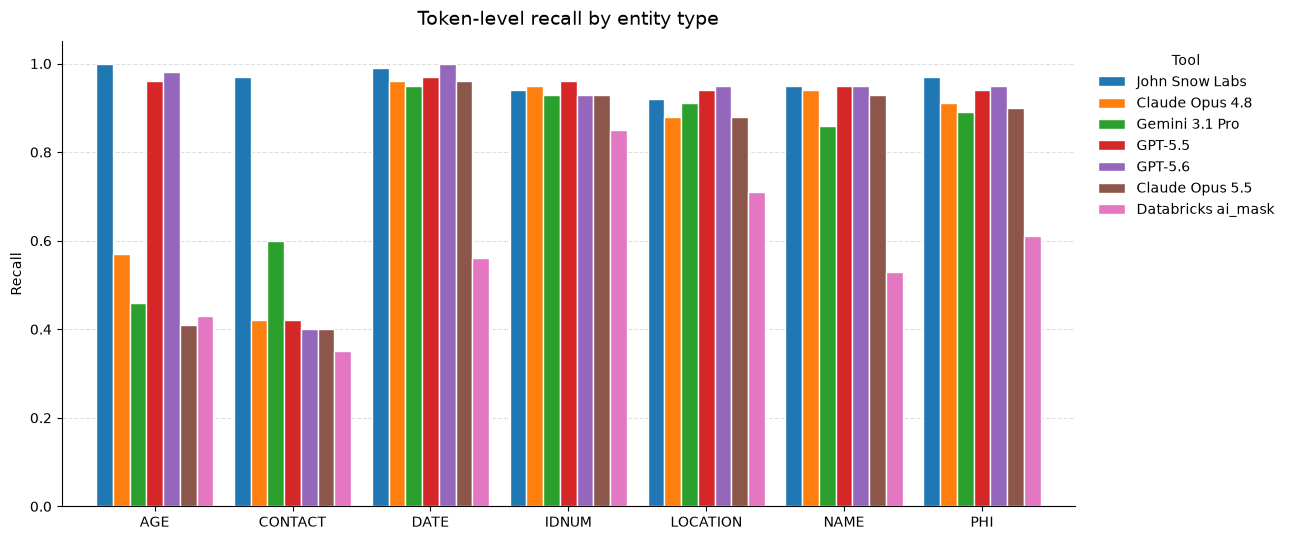

In [65]:
import matplotlib.pyplot as plt

ax = recall_df.loc[sorted(GT_LABELS) + ["PHI"]].astype(float).plot(
    kind="bar", figsize=(13, 5.5), width=0.85, edgecolor="white", linewidth=1)
ax.set_title("Token-level recall by entity type", fontsize=14, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.legend(title="Tool", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

## 14. Save the results

In [66]:
with pd.ExcelWriter(os.path.join(CACHE_DIR, "benchmark_results.xlsx")) as xw:
    final_df.to_excel(xw, sheet_name="Benchmark")
    recall_df.to_excel(xw, sheet_name="Recall")
    chunk_table.to_excel(xw, sheet_name="Chunk level")
    if len(diff_df):
        diff_df.to_excel(xw, sheet_name="Run vs published")

for name in TOOLS:
    slug = re.sub(r"[^\w]+", "_", name).strip("_").lower()
    pred_dfs[name].drop(columns=["text"], errors="ignore").to_csv(
        os.path.join(CACHE_DIR, f"{slug}_spans.csv"), index=False)
token_pred_df.to_csv(os.path.join(CACHE_DIR, "token_level.csv"), index=False)
print("written:", sorted(os.listdir(CACHE_DIR)))

# To download everything from Colab:
# !zip -qr benchmark_outputs.zip {CACHE_DIR}
# from google.colab import files; files.download("benchmark_outputs.zip")

written: ['benchmark_results.xlsx', 'token_level.csv']
